Analysis iteration 1 DUE 

In [152]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks


# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

In [153]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"

# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")


In [154]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate


In [155]:
def get_sniff_respiratory_rate(signal, times, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout.
    """
    sniff_mask = (times >= sniff_start) & (times < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.2)

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate


In [156]:
import pandas as pd

def calculate_agent_sniff_to_fight_latency(df):
    # Ensure correct data types
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)

    # Sort by time
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Agent-initiated face sniffs
    sniff_df = df[(df['Behavior'] == 'facial sniffing') & (df['Subject'] == 'social_agent')]

    # All fights (you can restrict to social_agent if needed)
    fight_df = df[df['Behavior'] == 'fighting']

    latencies = []

    for _, sniff in sniff_df.iterrows():
        sniff_end = sniff['Stop (s)']
        
        # Find the first fight *after* this sniff
        future_fights = fight_df[fight_df['Start (s)'] > sniff_end]
        
        if not future_fights.empty:
            next_fight = future_fights.iloc[0]
            latency = next_fight['Start (s)'] - sniff_end
            latencies.append({
                'Sniff End Time (s)': sniff_end,
                'Fight Start Time (s)': next_fight['Start (s)'],
                'Latency (s)': latency
            })
        else:
            latencies.append({
                'Sniff End Time (s)': sniff_end,
                'Fight Start Time (s)': None,
                'Latency (s)': None
            })

    return pd.DataFrame(latencies)


In [157]:
import pandas as pd

def calculate_agent_sniff_to_fight_latency(df):
    # Ensure correct data types
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)

    # Sort by time
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Agent-initiated face sniffs
    sniff_df = df[(df['Behavior'] == 'facial sniffing') & (df['Subject'] == 'social_agent')]

    # All fights (you can restrict to social_agent if needed)
    fight_df = df[df['Behavior'] == 'fighting']

    latencies = []

    for _, sniff in sniff_df.iterrows():
        sniff_start = sniff['Start (s)']
        sniff_end = sniff['Stop (s)']
        
        # Find the first fight *after* this sniff ends
        future_fights = fight_df[fight_df['Start (s)'] > sniff_end]
        
        if not future_fights.empty:
            next_fight = future_fights.iloc[0]
            latency = next_fight['Start (s)'] - sniff_end
            latencies.append({
                'Sniff Start Time (s)': sniff_start,
                'Sniff End Time (s)': sniff_end,
                'Fight Start Time (s)': next_fight['Start (s)'],
                'Latency (s)': latency
            })
        else:
            latencies.append({
                'Sniff Start Time (s)': sniff_start,
                'Sniff End Time (s)': sniff_end,
                'Fight Start Time (s)': None,
                'Latency (s)': None
            })

    return pd.DataFrame(latencies)


In [158]:
boris_df = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
latency_df = calculate_agent_sniff_to_fight_latency(boris_df)
print(latency_df)

    Sniff Start Time (s)  Sniff End Time (s)  Fight Start Time (s)  \
0                  6.767               7.667                15.733   
1                 13.767              14.967                15.733   
2                 29.633              30.367                38.167   
3                 37.567              37.867                38.167   
4                 66.300              68.133               105.467   
5                 99.333             100.099               105.467   
6                104.067             105.099               105.467   
7                298.300             304.800               305.533   
8                334.867             334.933               338.633   
9                409.867             410.100               430.800   
10               454.000             454.699               454.700   
11               471.633             472.133               522.067   
12               472.367             475.033               522.067   
13               495

In [159]:
latency_df

,Sniff Start Time (s),Sniff End Time (s),Fight Start Time (s),Latency (s)
0,6.767,7.667,15.733,8.066
1,13.767,14.967,15.733,0.766
2,29.633,30.367,38.167,7.800
3,37.567,37.867,38.167,0.300
4,66.300,68.133,105.467,37.334
5,99.333,100.099,105.467,5.368
6,104.067,105.099,105.467,0.368
7,298.300,304.800,305.533,0.733
8,334.867,334.933,338.633,3.700
9,409.867,410.100,430.800,20.700


In [160]:
def get_respiratory_rate(signal, times, sniff_time, sampling_rate=100, window=2):
    """
    Compute the change in breathing rate (Hz) around a sniff_time.
    """
    # Define time windows
    pre_start = sniff_time - window
    pre_end = sniff_time
    post_start = sniff_time
    post_end = sniff_time + window

    # Create masks
    pre_mask = (times >= pre_start) & (times < pre_end)
    post_mask = (times >= post_start) & (times < post_end)

    # Get segments
    signal_pre = signal[pre_mask]
    signal_post = signal[post_mask]

    # Get rate = number of peaks / duration
    pre_peaks, _ = find_peaks(signal_pre, distance=sampling_rate*0.2)  # 200 ms min gap
    post_peaks, _ = find_peaks(signal_post, distance=sampling_rate*0.2)

    # Compute rate in Hz (peaks per sec)
    rate_pre = len(pre_peaks) / window
    rate_post = len(post_peaks) / window

    delta_rate = rate_post - rate_pre
    return delta_rate

In [186]:
# Assuming you know the sampling rate (e.g., 100 Hz)
sampling_rate = 100  # or whatever your true rate is

# resp_signal is your 1D NumPy array of the cleaned respiration signal
# Example: shape = (1206544,) for 12065.44 sec at 100 Hz

resp_signal, times, sampling_rate = load_clean_resp_signal(RI2_4_7_h5_path)  # ← pick your file
if resp_signal is None:
    raise ValueError("Respiration loading failed")



In [162]:
results = []

for _, row in latency_df.iterrows():
    sniff_time = row["Sniff End Time (s)"]
    latency = row["Latency (s)"]
    
    if pd.isna(sniff_time) or pd.isna(latency):
        continue

    delta = get_respiratory_rate(resp_signal, times, sniff_time, sampling_rate=sampling_rate)

    results.append({
        "Sniff Time": sniff_time,
        "ΔRespRate": delta,
        "Latency (s)": latency
    })

resp_rate_df = pd.DataFrame(results)
print(resp_rate_df.head())



   Sniff Time  ΔRespRate  Latency (s)
0       7.667        1.0        8.066
1      14.967       -0.5        0.766
2      30.367       -0.5        7.800
3      37.867       -0.5        0.300
4      68.133        0.0       37.334


In [163]:
results = []

for _, row in latency_df.iterrows():
    sniff_start = row["Sniff Start Time (s)"]
    sniff_end = row["Sniff End Time (s)"]
    latency = row["Latency (s)"]

    if pd.isna(sniff_start) or pd.isna(sniff_end) or pd.isna(latency):
        continue

    rate = get_sniff_respiratory_rate(resp_signal, times, sniff_start, sniff_end)

    results.append({
        "Sniff Rate (Hz)": rate,
        "Latency (s)": latency
    })

resp_rate_df = pd.DataFrame(results)


In [164]:
print(latency_df.columns.tolist())


['Sniff Start Time (s)', 'Sniff End Time (s)', 'Fight Start Time (s)', 'Latency (s)']


In [165]:
print(latency_df[latency_df["Latency (s)"] < 0])


Empty DataFrame
Columns: [Sniff Start Time (s), Sniff End Time (s), Fight Start Time (s), Latency (s)]
Index: []


In [166]:
resp_rate_df

,Sniff Rate (Hz),Latency (s)
0,2.222222,8.066
1,4.166667,0.766
2,4.087193,7.800
3,6.666667,0.300
4,3.273322,37.334
5,3.916449,5.368
6,2.906977,0.368
7,3.076923,0.733
8,0.000000,3.700
9,4.291845,20.700


In [167]:
def get_sniff_respiratory_rate(signal, times, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout.
    """
    sniff_mask = (times >= sniff_start) & (times < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.2)  # ~200 ms min gap

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate


In [168]:
results = []

for _, row in latency_df.iterrows():
    sniff_start = row["Sniff Start Time (s)"]
    sniff_end = row["Sniff End Time (s)"]
    latency = row["Latency (s)"]

    if pd.isna(sniff_start) or pd.isna(sniff_end) or pd.isna(latency):
        continue

    rate = get_sniff_respiratory_rate(resp_signal, times, sniff_start, sniff_end)

    results.append({
        "Sniff Rate (Hz)": rate,
        "Latency (s)": latency
    })

resp_rate_df = pd.DataFrame(results)


In [169]:
resp_rate_df

,Sniff Rate (Hz),Latency (s)
0,2.222222,8.066
1,4.166667,0.766
2,4.087193,7.800
3,6.666667,0.300
4,3.273322,37.334
5,3.916449,5.368
6,2.906977,0.368
7,3.076923,0.733
8,0.000000,3.700
9,4.291845,20.700


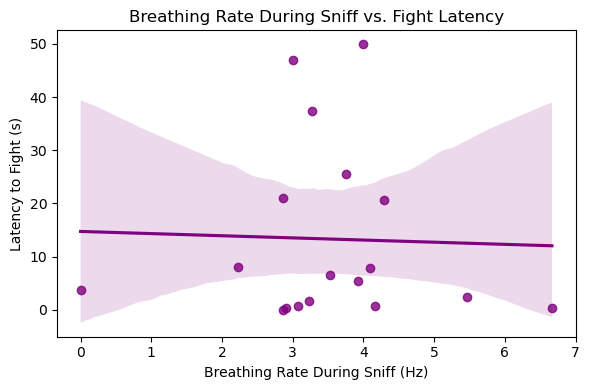

In [170]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.figure(figsize=(6, 4))
sns.regplot(data=resp_rate_df, x="Sniff Rate (Hz)", y="Latency (s)", color="purple")
plt.xlabel("Breathing Rate During Sniff (Hz)")
plt.ylabel("Latency to Fight (s)")
plt.title("Breathing Rate During Sniff vs. Fight Latency")
plt.tight_layout()
plt.show()


This function get_delta_resp_rate:

Calculates the absolute difference in breathing rate (Hz) after vs. before a given sniff_end time.

Uses a symmetric time window of length window seconds before and after sniff_end.

It counts peaks (breaths) in each window, divides by window duration for breathing rate, then returns the difference (post - pre).

How it works:
pre_mask: time window [sniff_end - window, sniff_end)

post_mask: time window [sniff_end, sniff_end + window)

Breathing rate before sniff_end = breaths counted in pre_mask ÷ window

Breathing rate after sniff_end = breaths counted in post_mask ÷ window

delta_rate = rate_post - rate_pre

Summary:
This function measures how breathing rate changes immediately around the end of a sniff event.

It returns a value in Hz (breaths per second), not percent change.

Useful if you want to see if breathing accelerates or slows down right after sniff ends.

In [171]:
from scipy.signal import find_peaks

def get_delta_resp_rate(signal, times, sniff_end, sampling_rate=100, window=2):
    """
    Calculate change in breathing rate (Hz) post-sniff vs pre-sniff around sniff_end.
    Pre window: sniff_end - window to sniff_end
    Post window: sniff_end to sniff_end + window
    """
    pre_start = sniff_end - window
    pre_end = sniff_end
    post_start = sniff_end
    post_end = sniff_end + window

    pre_mask = (times >= pre_start) & (times < pre_end)
    post_mask = (times >= post_start) & (times < post_end)

    signal_pre = signal[pre_mask]
    signal_post = signal[post_mask]

    pre_peaks, _ = find_peaks(signal_pre, distance=sampling_rate*0.2)
    post_peaks, _ = find_peaks(signal_post, distance=sampling_rate*0.2)

    rate_pre = len(pre_peaks) / window
    rate_post = len(post_peaks) / window

    delta_rate = rate_post - rate_pre

    return delta_rate


In [172]:
results = []

for _, row in latency_df.iterrows():
    sniff_end = row["Sniff End Time (s)"]
    latency = row["Latency (s)"]

    if pd.isna(sniff_end) or pd.isna(latency):
        continue

    delta_rate = get_delta_resp_rate(resp_signal, times, sniff_end)

    results.append({
        "ΔRespRate (Hz)": delta_rate,
        "Latency (s)": latency
    })

resp_rate_df = pd.DataFrame(results)


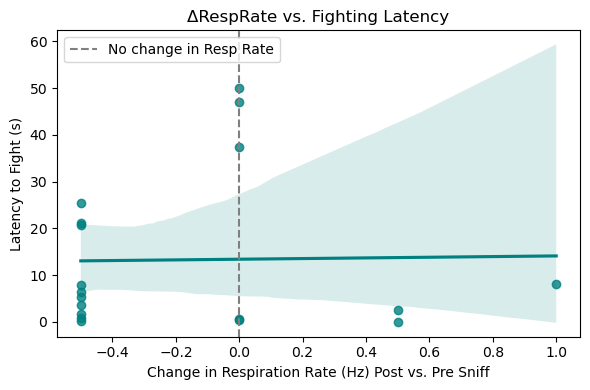

Pearson r = 0.02, p = 0.939


In [173]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.figure(figsize=(6,4))
sns.regplot(data=resp_rate_df, x="ΔRespRate (Hz)", y="Latency (s)", color="teal")
plt.axvline(0, linestyle='--', color='gray', label='No change in Resp Rate')
plt.xlabel("Change in Respiration Rate (Hz) Post vs. Pre Sniff")
plt.ylabel("Latency to Fight (s)")
plt.title("ΔRespRate vs. Fighting Latency")
plt.legend()
plt.tight_layout()
plt.show()

r, p = pearsonr(resp_rate_df["ΔRespRate (Hz)"], resp_rate_df["Latency (s)"])
print(f"Pearson r = {r:.2f}, p = {p:.3f}")


This function get_percent_change_resp_rate is related but different from get_respiratory_rate:

What it does:
It calculates the percent change in breathing rate during a sniff bout relative to a baseline period before the sniff.

Inputs:

sniff_start, sniff_end — window of the sniff bout

baseline_window (default 4 seconds) — time before sniff start used for baseline

How it works:

Computes baseline breathing rate in the baseline window before sniff start

Computes sniff breathing rate during the sniff window

Returns percent change = ((sniff rate - baseline rate) / baseline rate) * 100

In contrast:
get_respiratory_rate computes the absolute difference (post - pre) breathing rate change in a symmetric window around a single time (sniff_time).



In [174]:
def get_percent_change_resp_rate(signal, times, sniff_start, sniff_end, sampling_rate=100, baseline_window=4):
    """
    Calculate % change in breathing rate during sniff relative to baseline before sniff.
    """
    baseline_start = sniff_start - baseline_window
    baseline_end = sniff_start

    # Masks for baseline and sniff windows
    baseline_mask = (times >= baseline_start) & (times < baseline_end)
    sniff_mask = (times >= sniff_start) & (times < sniff_end)

    signal_baseline = signal[baseline_mask]
    signal_sniff = signal[sniff_mask]

    peaks_baseline, _ = find_peaks(signal_baseline, distance=sampling_rate * 0.2)
    peaks_sniff, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.2)

    baseline_duration = baseline_end - baseline_start
    sniff_duration = sniff_end - sniff_start

    # Calculate rates (Hz)
    rate_baseline = len(peaks_baseline) / baseline_duration if baseline_duration > 0 else np.nan
    rate_sniff = len(peaks_sniff) / sniff_duration if sniff_duration > 0 else np.nan

    if rate_baseline == 0 or np.isnan(rate_baseline):
        return np.nan  # avoid division by zero or invalid baseline

    percent_change = ((rate_sniff - rate_baseline) / rate_baseline) * 100
    return percent_change


In [175]:
results = []

for _, row in latency_df.iterrows():
    sniff_start = row["Sniff Start Time (s)"]
    sniff_end = row["Sniff End Time (s)"]
    latency = row["Latency (s)"]

    if pd.isna(sniff_start) or pd.isna(sniff_end) or pd.isna(latency):
        continue

    pct_change = get_percent_change_resp_rate(resp_signal, times, sniff_start, sniff_end)

    results.append({
        "%Resp Rate Change": pct_change,
        "Latency (s)": latency
    })

resp_rate_df = pd.DataFrame(results)


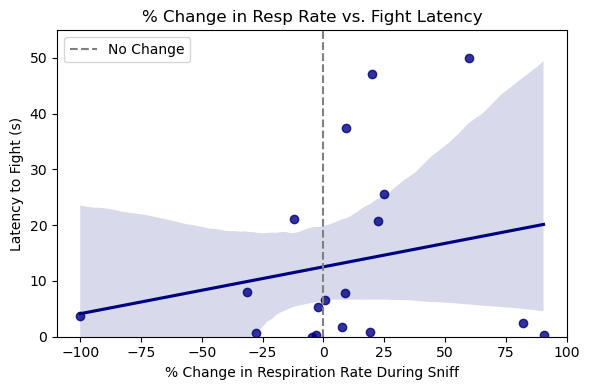

Pearson r = 0.22, p = 0.387


In [185]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Calculate clean Y-axis limits
min_latency = 0
max_latency = resp_rate_df["Latency (s)"].max()
buffer = 2 if max_latency < 10 else max_latency * 0.1  # Add enough top buffer

plt.figure(figsize=(6, 4))
sns.regplot(data=resp_rate_df, x="%Resp Rate Change", y="Latency (s)", color="navy")

# Visual guide
plt.axvline(0, linestyle='--', color='gray', label='No Change')
plt.xlabel("% Change in Respiration Rate During Sniff")
plt.ylabel("Latency to Fight (s)")
plt.title("% Change in Resp Rate vs. Fight Latency")

# Final Y-axis tweak
plt.ylim(min_latency, max_latency + buffer)

plt.legend()
plt.tight_layout()
plt.show()

# Optional: stats
r, p = pearsonr(resp_rate_df["%Resp Rate Change"], resp_rate_df["Latency (s)"])
print(f"Pearson r = {r:.2f}, p = {p:.3f}")



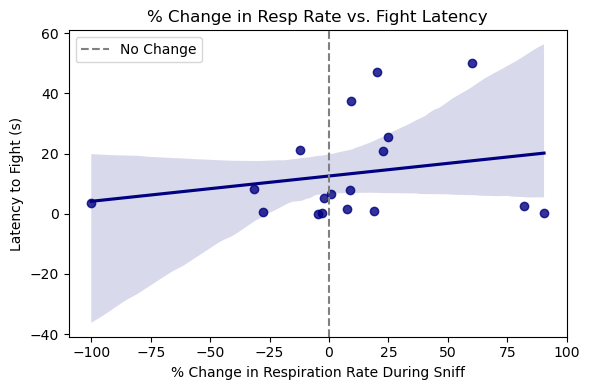

Pearson r = 0.22, p = 0.387


In [182]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.figure(figsize=(6,4))
sns.regplot(data=resp_rate_df, x="%Resp Rate Change", y="Latency (s)", color="navy")
plt.axvline(0, linestyle='--', color='gray', label='No Change')

plt.xlabel("% Change in Respiration Rate During Sniff")
plt.ylabel("Latency to Fight (s)")
plt.title("% Change in Resp Rate vs. Fight Latency")
plt.legend()
plt.tight_layout()
plt.show()



r, p = pearsonr(resp_rate_df["%Resp Rate Change"], resp_rate_df["Latency (s)"])
print(f"Pearson r = {r:.2f}, p = {p:.3f}")


In [177]:
latency_df

,Sniff Start Time (s),Sniff End Time (s),Fight Start Time (s),Latency (s)
0,6.767,7.667,15.733,8.066
1,13.767,14.967,15.733,0.766
2,29.633,30.367,38.167,7.800
3,37.567,37.867,38.167,0.300
4,66.300,68.133,105.467,37.334
5,99.333,100.099,105.467,5.368
6,104.067,105.099,105.467,0.368
7,298.300,304.800,305.533,0.733
8,334.867,334.933,338.633,3.700
9,409.867,410.100,430.800,20.700


Plotting behavior bouts

In [178]:
def extract_resp_around_behavior(resp_signal, time_axis, behavior_df, sampling_rate=100, window=2.0):
    segments = []

    behavior_df = behavior_df[behavior_df['Duration (s)'] >= 1.0]
    for _, row in behavior_df.iterrows():
        start_time = row['Start (s)']
        behavior = row['Behavior']

        # Define window: 1s before to 1s after behavior start
        win_start = start_time - window / 2
        win_end = start_time + window / 2

        # Find indices
        idx_start = np.searchsorted(time_axis, win_start)
        idx_end = np.searchsorted(time_axis, win_end)

        # Extract segment
        if 0 <= idx_start < idx_end <= len(resp_signal):
            segment = resp_signal[idx_start:idx_end]
            segments.append((behavior, segment))

    return segments


In [179]:
def plot_segments(segments, sampling_rate=100):
    for i, (behavior, segment) in enumerate(segments):
        plt.figure(figsize=(5, 2))
        t = np.arange(len(segment)) / sampling_rate
        plt.plot(t, segment)
        plt.title(f"{behavior} (Trial {i+1})")
        plt.xlabel("Time (s)")
        plt.ylabel("Resp Signal")
        plt.tight_layout()
        plt.show()


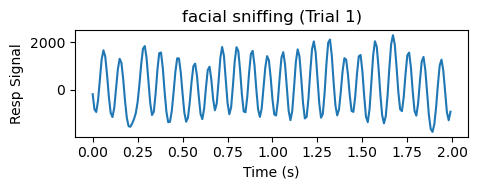

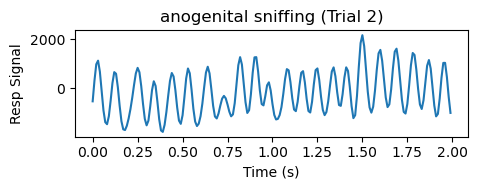

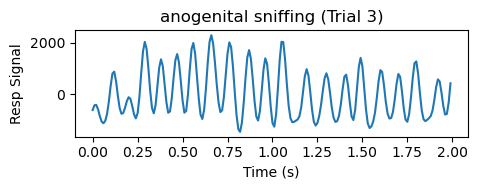

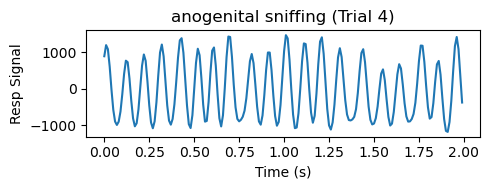

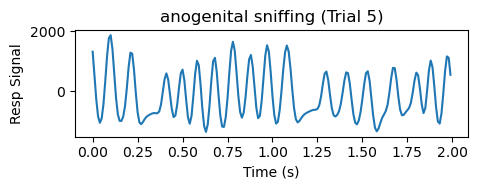

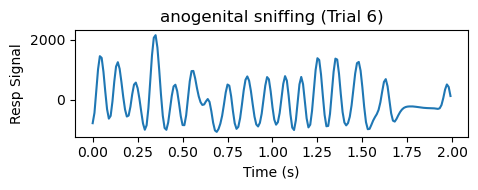

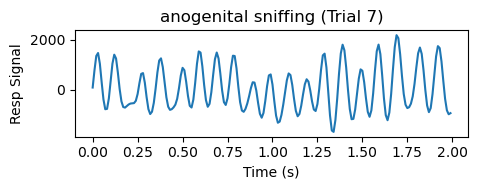

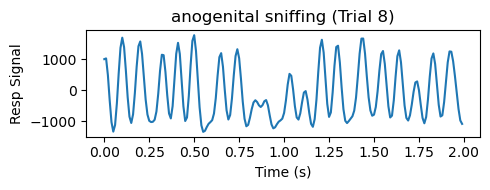

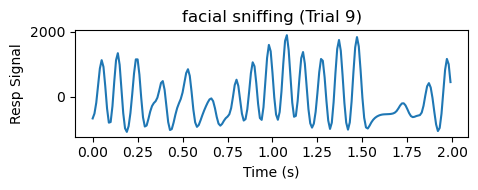

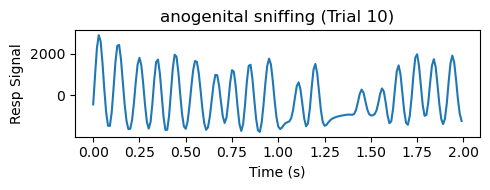

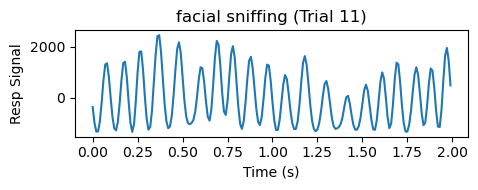

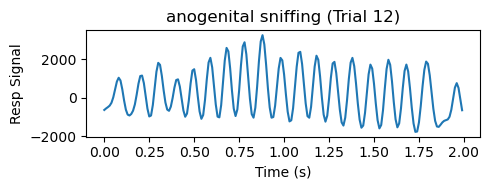

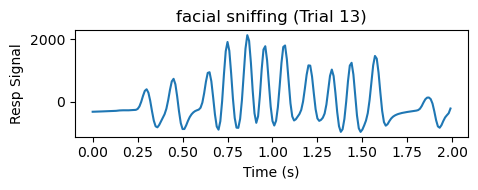

In [180]:
resp_signal, time_axis = get_kit(RI1_3_6_h5_path)
segments = extract_resp_around_behavior(resp_signal, time_axis, RI1_3_6_boris, sampling_rate=100)
plot_segments(segments)
